In [33]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


weather = pd.read_csv("weather data.csv", index_col="DATE", parse_dates=True)
weather = weather[weather["STATION"] == "JA000047662"]




In [34]:
weather

,STATION,NAME,AWND,FMTM,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,...,WT07,WT08,WT11,WT13,WT14,WT16,WT18,WT21,WT22,WV20
DATE,,,,,,,,,,,,,,,,,,,,,
1980-01-01,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.00,NaN,NaN,42.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-02,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.04,NaN,NaN,42.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-03,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.47,NaN,NaN,46.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-04,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.45,NaN,NaN,48.0,57.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1980-01-05,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.04,NaN,NaN,38.0,49.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-22,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.00,NaN,NaN,63.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-23,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.00,NaN,NaN,62.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-24,JA000047662,"TOKYO, JA",NaN,NaN,NaN,0.00,NaN,NaN,59.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
null_pct = weather.apply(pd.isnull).sum()/weather.shape[0]

In [36]:
null_pct

STATION    0.000000
NAME       0.000000
AWND       1.000000
FMTM       1.000000
PGTM       1.000000
PRCP       0.227433
SNOW       1.000000
SNWD       0.993805
TAVG       0.000000
TMAX       0.186358
TMIN       0.328852
WDF2       1.000000
WDFG       1.000000
WSF2       1.000000
WSFG       1.000000
WT01       1.000000
WT02       1.000000
WT03       1.000000
WT04       1.000000
WT05       1.000000
WT07       1.000000
WT08       1.000000
WT11       1.000000
WT13       1.000000
WT14       1.000000
WT16       1.000000
WT18       1.000000
WT21       1.000000
WT22       1.000000
WV20       1.000000
dtype: float64

In [37]:
valid_columns = weather.columns[null_pct<0.5]

In [38]:
valid_columns


Index(['STATION', 'NAME', 'PRCP', 'TAVG', 'TMAX', 'TMIN'], dtype='object')

In [39]:
type(weather)

pandas.core.frame.DataFrame

In [40]:
weather = weather[valid_columns].copy()

In [41]:
weather = weather.ffill()

In [42]:
weather.apply(pd.isnull).sum()

STATION    0
NAME       0
PRCP       0
TAVG       0
TMAX       0
TMIN       0
dtype: int64

In [43]:
weather.dtypes

STATION     object
NAME        object
PRCP       float64
TAVG       float64
TMAX       float64
TMIN       float64
dtype: object

In [44]:
weather.index

DatetimeIndex(['1980-01-01', '1980-01-02', '1980-01-03', '1980-01-04',
               '1980-01-05', '1980-01-06', '1980-01-07', '1980-01-08',
               '1980-01-09', '1980-01-10',
               ...
               '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
               '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24',
               '2025-03-25', '2025-03-26'],
              dtype='datetime64[ns]', name='DATE', length=16141, freq=None)

In [45]:
weather.index

DatetimeIndex(['1980-01-01', '1980-01-02', '1980-01-03', '1980-01-04',
               '1980-01-05', '1980-01-06', '1980-01-07', '1980-01-08',
               '1980-01-09', '1980-01-10',
               ...
               '2025-03-17', '2025-03-18', '2025-03-19', '2025-03-20',
               '2025-03-21', '2025-03-22', '2025-03-23', '2025-03-24',
               '2025-03-25', '2025-03-26'],
              dtype='datetime64[ns]', name='DATE', length=16141, freq=None)

In [46]:
weather.index = pd.to_datetime(weather.index)

In [47]:
weather.index.year.value_counts().sort_index()

DATE
1980    366
1981    365
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    364
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    365
1999    364
2000    366
2001    365
2002    365
2003    365
2004    366
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    362
2022    365
2023    365
2024    355
2025     85
Name: count, dtype: int64

In [48]:
weather = weather.loc[~weather.index.duplicated(keep='first')]

In [49]:
print(weather.index.year.value_counts().sort_index())

DATE
1980    366
1981    365
1982    365
1983    365
1984    366
1985    365
1986    365
1987    365
1988    366
1989    365
1990    365
1991    364
1992    366
1993    365
1994    365
1995    365
1996    366
1997    365
1998    365
1999    364
2000    366
2001    365
2002    365
2003    365
2004    366
2006    365
2007    365
2008    366
2009    365
2010    365
2011    365
2012    366
2013    365
2014    365
2015    365
2016    366
2017    365
2018    365
2019    365
2020    366
2021    362
2022    365
2023    365
2024    355
2025     85
Name: count, dtype: int64


In [50]:
weather

,STATION,NAME,PRCP,TAVG,TMAX,TMIN
DATE,,,,,,
1980-01-01,JA000047662,"TOKYO, JA",0.00,42.0,50.0,39.0
1980-01-02,JA000047662,"TOKYO, JA",0.04,42.0,46.0,35.0
1980-01-03,JA000047662,"TOKYO, JA",0.47,46.0,50.0,38.0
1980-01-04,JA000047662,"TOKYO, JA",0.45,48.0,57.0,43.0
1980-01-05,JA000047662,"TOKYO, JA",0.04,38.0,49.0,36.0
...,...,...,...,...,...,...
2025-03-22,JA000047662,"TOKYO, JA",0.00,63.0,57.0,44.0
2025-03-23,JA000047662,"TOKYO, JA",0.00,62.0,57.0,44.0
2025-03-24,JA000047662,"TOKYO, JA",0.00,59.0,57.0,50.0


In [51]:
weather["target"] = weather.shift(-1)["TMAX"]

In [52]:
weather


,STATION,NAME,PRCP,TAVG,TMAX,TMIN,target
DATE,,,,,,,
1980-01-01,JA000047662,"TOKYO, JA",0.00,42.0,50.0,39.0,46.0
1980-01-02,JA000047662,"TOKYO, JA",0.04,42.0,46.0,35.0,50.0
1980-01-03,JA000047662,"TOKYO, JA",0.47,46.0,50.0,38.0,57.0
1980-01-04,JA000047662,"TOKYO, JA",0.45,48.0,57.0,43.0,49.0
1980-01-05,JA000047662,"TOKYO, JA",0.04,38.0,49.0,36.0,53.0
...,...,...,...,...,...,...,...
2025-03-22,JA000047662,"TOKYO, JA",0.00,63.0,57.0,44.0,57.0
2025-03-23,JA000047662,"TOKYO, JA",0.00,62.0,57.0,44.0,57.0
2025-03-24,JA000047662,"TOKYO, JA",0.00,59.0,57.0,50.0,57.0


In [53]:
from sklearn.linear_model import Ridge
regression = Ridge(alpha=0.1)



In [54]:
predictors = weather.columns[~weather.columns.isin(["target", "STATION", "NAME"])]
predictors = [col for col in weather.columns if col not in ["DATE", "target"]]

predictors = weather.select_dtypes(include=["float64"]).drop(columns=["target"]).columns


In [55]:
predictors


Index(['PRCP', 'TAVG', 'TMAX', 'TMIN'], dtype='object')

In [56]:
def backtest(weather, model, predictors, start =3650, step = 30):
    all_predictions = []

    for i in range(start, weather.shape[0], step):
        train = weather.iloc[:i, :]
        test = weather.iloc[i: i+step, :]

        model.fit(train[predictors], train ["target"])

        preds = model.predict(test[predictors])

        preds = pd.Series(preds, index = test.index)
        combined = pd.concat([test["target"], preds], axis=1)

        combined.columns = ["actual", "predictions"]

        combined["diff"] = (combined["predictions"] - combined["actual"]).abs()

        all_predictions.append(combined)
    return pd.concat(all_predictions)


In [57]:
predictions = backtest(weather, regression, predictors)

In [58]:
predictions

,actual,predictions,diff
DATE,,,
1989-12-29,51.0,53.864930,2.864930
1989-12-30,50.0,51.243134,1.243134
1989-12-31,50.0,49.010518,0.989482
1990-01-01,49.0,47.699620,1.300380
1990-01-02,48.0,49.430323,1.430323
...,...,...,...
2025-03-22,57.0,57.040595,0.040595
2025-03-23,57.0,57.077437,0.077437
2025-03-24,57.0,57.994208,0.994208


In [59]:
weather.reset_index(inplace=True)


In [60]:
predictions["diff"].mean()

np.float64(3.9687520151548705)

In [61]:
def pct_diff(old, new):
    return (new-old)/old

def compute_rolling(weather, horizon, col):
    label = f"rolling_{horizon}_{col}"

    weather[label] = weather[col].rolling(horizon).mean()
    weather[f"{label}_pct"] = pct_diff(weather[label], weather[col])
    return weather

rolling_horizons = [3, 14]

for horizon in rolling_horizons:
    for col in ["TMAX", "TMIN", "PRCP"]:
        weather = compute_rolling(weather, horizon, col)


In [62]:
weather = weather.iloc[14:, :]

In [63]:
weather

,DATE,STATION,NAME,PRCP,TAVG,TMAX,TMIN,target,rolling_3_TMAX,rolling_3_TMAX_pct,rolling_3_TMIN,rolling_3_TMIN_pct,rolling_3_PRCP,rolling_3_PRCP_pct,rolling_14_TMAX,rolling_14_TMAX_pct,rolling_14_TMIN,rolling_14_TMIN_pct,rolling_14_PRCP,rolling_14_PRCP_pct
14,1980-01-15,JA000047662,"TOKYO, JA",0.0,39.0,51.0,32.0,51.0,47.666667,0.069930,33.000000,-0.030303,0.303333,-1.0,48.857143,0.043860,34.642857,-0.076289,0.137857,-1.0
15,1980-01-16,JA000047662,"TOKYO, JA",0.0,40.0,51.0,32.0,50.0,51.666667,-0.012903,32.333333,-0.010309,0.000000,NaN,49.214286,0.036284,34.428571,-0.070539,0.135000,-1.0
16,1980-01-17,JA000047662,"TOKYO, JA",0.0,42.0,50.0,32.0,48.0,50.666667,-0.013158,32.000000,0.000000,0.000000,NaN,49.214286,0.015965,34.000000,-0.058824,0.101429,-1.0
17,1980-01-18,JA000047662,"TOKYO, JA",0.0,39.0,48.0,31.0,48.0,49.666667,-0.033557,31.666667,-0.021053,0.000000,NaN,48.571429,-0.011765,33.142857,-0.064655,0.069286,-1.0
18,1980-01-19,JA000047662,"TOKYO, JA",0.0,42.0,48.0,33.0,54.0,48.666667,-0.013699,32.000000,0.031250,0.000000,NaN,48.500000,-0.010309,32.928571,0.002169,0.066429,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16136,2025-03-22,JA000047662,"TOKYO, JA",0.0,63.0,57.0,44.0,57.0,57.000000,0.000000,41.000000,0.073171,0.100000,-1.0,57.000000,0.000000,42.357143,0.038786,0.229286,-1.0
16137,2025-03-23,JA000047662,"TOKYO, JA",0.0,62.0,57.0,44.0,57.0,57.000000,0.000000,42.333333,0.039370,0.000000,NaN,57.000000,0.000000,43.142857,0.019868,0.202857,-1.0
16138,2025-03-24,JA000047662,"TOKYO, JA",0.0,59.0,57.0,50.0,57.0,57.000000,0.000000,46.000000,0.086957,0.000000,NaN,57.000000,0.000000,44.000000,0.136364,0.202857,-1.0
16139,2025-03-25,JA000047662,"TOKYO, JA",0.0,68.0,57.0,50.0,57.0,57.000000,0.000000,48.000000,0.041667,0.000000,NaN,57.000000,0.000000,44.500000,0.123596,0.202857,-1.0


In [64]:
weather = weather.fillna(0)

In [65]:
weather.index = pd.to_datetime(weather.index)

In [66]:
def expand_mean(df):
    return df.expanding(1).mean()

for col in ["TMAX", "TMIN", "PRCP"]:
    weather[f"month_avg_{col}"] = weather[col].groupby(weather.index.month, group_keys=False).apply(expand_mean)
    weather[f"day_avg_{col}"] = weather[col].groupby(weather.index.day_of_year, group_keys=False).apply(expand_mean)



In [67]:
weather

,DATE,STATION,NAME,PRCP,TAVG,TMAX,TMIN,target,rolling_3_TMAX,rolling_3_TMAX_pct,...,rolling_14_TMIN,rolling_14_TMIN_pct,rolling_14_PRCP,rolling_14_PRCP_pct,month_avg_TMAX,day_avg_TMAX,month_avg_TMIN,day_avg_TMIN,month_avg_PRCP,day_avg_PRCP
1970-01-01 00:00:00.000000014,1980-01-15,JA000047662,"TOKYO, JA",0.0,39.0,51.0,32.0,51.0,47.666667,0.069930,...,34.642857,-0.076289,0.137857,-1.0,51.000000,51.000000,32.000000,32.000000,0.000000,0.000000
1970-01-01 00:00:00.000000015,1980-01-16,JA000047662,"TOKYO, JA",0.0,40.0,51.0,32.0,50.0,51.666667,-0.012903,...,34.428571,-0.070539,0.135000,-1.0,51.000000,51.000000,32.000000,32.000000,0.000000,0.000000
1970-01-01 00:00:00.000000016,1980-01-17,JA000047662,"TOKYO, JA",0.0,42.0,50.0,32.0,48.0,50.666667,-0.013158,...,34.000000,-0.058824,0.101429,-1.0,50.666667,50.666667,32.000000,32.000000,0.000000,0.000000
1970-01-01 00:00:00.000000017,1980-01-18,JA000047662,"TOKYO, JA",0.0,39.0,48.0,31.0,48.0,49.666667,-0.033557,...,33.142857,-0.064655,0.069286,-1.0,50.000000,50.000000,31.750000,31.750000,0.000000,0.000000
1970-01-01 00:00:00.000000018,1980-01-19,JA000047662,"TOKYO, JA",0.0,42.0,48.0,33.0,54.0,48.666667,-0.013699,...,32.928571,0.002169,0.066429,-1.0,49.600000,49.600000,32.000000,32.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000016136,2025-03-22,JA000047662,"TOKYO, JA",0.0,63.0,57.0,44.0,57.0,57.000000,0.000000,...,42.357143,0.038786,0.229286,-1.0,68.669913,68.669913,55.343422,55.343422,0.278749,0.278749
1970-01-01 00:00:00.000016137,2025-03-23,JA000047662,"TOKYO, JA",0.0,62.0,57.0,44.0,57.0,57.000000,0.000000,...,43.142857,0.019868,0.202857,-1.0,68.669189,68.669189,55.342719,55.342719,0.278732,0.278732
1970-01-01 00:00:00.000016138,2025-03-24,JA000047662,"TOKYO, JA",0.0,59.0,57.0,50.0,57.0,57.000000,0.000000,...,44.000000,0.136364,0.202857,-1.0,68.668465,68.668465,55.342388,55.342388,0.278714,0.278714
1970-01-01 00:00:00.000016139,2025-03-25,JA000047662,"TOKYO, JA",0.0,68.0,57.0,50.0,57.0,57.000000,0.000000,...,44.500000,0.123596,0.202857,-1.0,68.667742,68.667742,55.342056,55.342056,0.278697,0.278697


In [68]:
predictors = weather.columns[~weather.columns.isin(["target", "STATION", "NAME"])]

In [69]:
predictors

Index(['DATE', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'rolling_3_TMAX',
       'rolling_3_TMAX_pct', 'rolling_3_TMIN', 'rolling_3_TMIN_pct',
       'rolling_3_PRCP', 'rolling_3_PRCP_pct', 'rolling_14_TMAX',
       'rolling_14_TMAX_pct', 'rolling_14_TMIN', 'rolling_14_TMIN_pct',
       'rolling_14_PRCP', 'rolling_14_PRCP_pct', 'month_avg_TMAX',
       'day_avg_TMAX', 'month_avg_TMIN', 'day_avg_TMIN', 'month_avg_PRCP',
       'day_avg_PRCP'],
      dtype='object')

In [70]:
predictors = list(predictors)  
if "DATE" in predictors:
    predictors.remove("DATE")


In [71]:
predictions["diff"].mean()

np.float64(3.9687520151548705)

In [72]:
predictions.sort_values("diff", ascending=False)

,actual,predictions,diff
DATE,,,
2014-08-02,96.0,58.020591,37.979409
2013-12-29,88.0,57.961937,30.038063
2013-12-28,88.0,58.510746,29.489254
2013-08-10,71.0,100.162815,29.162815
2013-12-20,88.0,58.916544,29.083456
...,...,...,...
2024-03-23,55.0,54.998793,0.001207
1995-02-16,50.0,49.999159,0.000841
2007-12-08,58.0,57.999633,0.000367


<Axes: xlabel='diff'>

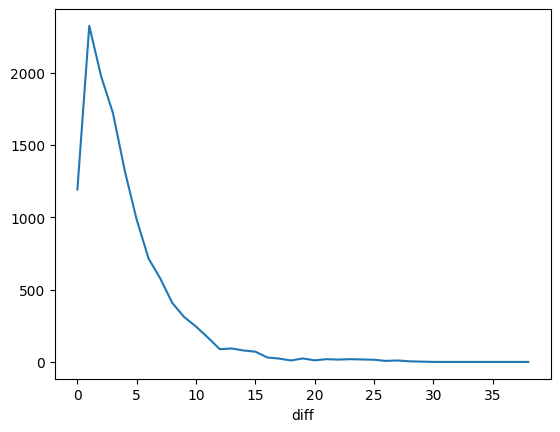

In [73]:
(predictions["diff"].round().value_counts()).sort_index().plot()

In [74]:
print(weather.index)


DatetimeIndex(['1970-01-01 00:00:00.000000014',
               '1970-01-01 00:00:00.000000015',
               '1970-01-01 00:00:00.000000016',
               '1970-01-01 00:00:00.000000017',
               '1970-01-01 00:00:00.000000018',
               '1970-01-01 00:00:00.000000019',
               '1970-01-01 00:00:00.000000020',
               '1970-01-01 00:00:00.000000021',
               '1970-01-01 00:00:00.000000022',
               '1970-01-01 00:00:00.000000023',
               ...
               '1970-01-01 00:00:00.000016131',
               '1970-01-01 00:00:00.000016132',
               '1970-01-01 00:00:00.000016133',
               '1970-01-01 00:00:00.000016134',
               '1970-01-01 00:00:00.000016135',
               '1970-01-01 00:00:00.000016136',
               '1970-01-01 00:00:00.000016137',
               '1970-01-01 00:00:00.000016138',
               '1970-01-01 00:00:00.000016139',
               '1970-01-01 00:00:00.000016140'],
              dtype=

In [75]:
weather

,DATE,STATION,NAME,PRCP,TAVG,TMAX,TMIN,target,rolling_3_TMAX,rolling_3_TMAX_pct,...,rolling_14_TMIN,rolling_14_TMIN_pct,rolling_14_PRCP,rolling_14_PRCP_pct,month_avg_TMAX,day_avg_TMAX,month_avg_TMIN,day_avg_TMIN,month_avg_PRCP,day_avg_PRCP
1970-01-01 00:00:00.000000014,1980-01-15,JA000047662,"TOKYO, JA",0.0,39.0,51.0,32.0,51.0,47.666667,0.069930,...,34.642857,-0.076289,0.137857,-1.0,51.000000,51.000000,32.000000,32.000000,0.000000,0.000000
1970-01-01 00:00:00.000000015,1980-01-16,JA000047662,"TOKYO, JA",0.0,40.0,51.0,32.0,50.0,51.666667,-0.012903,...,34.428571,-0.070539,0.135000,-1.0,51.000000,51.000000,32.000000,32.000000,0.000000,0.000000
1970-01-01 00:00:00.000000016,1980-01-17,JA000047662,"TOKYO, JA",0.0,42.0,50.0,32.0,48.0,50.666667,-0.013158,...,34.000000,-0.058824,0.101429,-1.0,50.666667,50.666667,32.000000,32.000000,0.000000,0.000000
1970-01-01 00:00:00.000000017,1980-01-18,JA000047662,"TOKYO, JA",0.0,39.0,48.0,31.0,48.0,49.666667,-0.033557,...,33.142857,-0.064655,0.069286,-1.0,50.000000,50.000000,31.750000,31.750000,0.000000,0.000000
1970-01-01 00:00:00.000000018,1980-01-19,JA000047662,"TOKYO, JA",0.0,42.0,48.0,33.0,54.0,48.666667,-0.013699,...,32.928571,0.002169,0.066429,-1.0,49.600000,49.600000,32.000000,32.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 00:00:00.000016136,2025-03-22,JA000047662,"TOKYO, JA",0.0,63.0,57.0,44.0,57.0,57.000000,0.000000,...,42.357143,0.038786,0.229286,-1.0,68.669913,68.669913,55.343422,55.343422,0.278749,0.278749
1970-01-01 00:00:00.000016137,2025-03-23,JA000047662,"TOKYO, JA",0.0,62.0,57.0,44.0,57.0,57.000000,0.000000,...,43.142857,0.019868,0.202857,-1.0,68.669189,68.669189,55.342719,55.342719,0.278732,0.278732
1970-01-01 00:00:00.000016138,2025-03-24,JA000047662,"TOKYO, JA",0.0,59.0,57.0,50.0,57.0,57.000000,0.000000,...,44.000000,0.136364,0.202857,-1.0,68.668465,68.668465,55.342388,55.342388,0.278714,0.278714
1970-01-01 00:00:00.000016139,2025-03-25,JA000047662,"TOKYO, JA",0.0,68.0,57.0,50.0,57.0,57.000000,0.000000,...,44.500000,0.123596,0.202857,-1.0,68.667742,68.667742,55.342056,55.342056,0.278697,0.278697


In [76]:
weather['DATE'] = pd.to_datetime(weather['DATE'], errors='coerce')
weather.set_index('DATE', inplace=True)


In [77]:
predictions

,actual,predictions,diff
DATE,,,
1989-12-29,51.0,53.864930,2.864930
1989-12-30,50.0,51.243134,1.243134
1989-12-31,50.0,49.010518,0.989482
1990-01-01,49.0,47.699620,1.300380
1990-01-02,48.0,49.430323,1.430323
...,...,...,...
2025-03-22,57.0,57.040595,0.040595
2025-03-23,57.0,57.077437,0.077437
2025-03-24,57.0,57.994208,0.994208


In [78]:
weather = weather.reset_index(drop=True)
print(weather.columns)


Index(['STATION', 'NAME', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'target',
       'rolling_3_TMAX', 'rolling_3_TMAX_pct', 'rolling_3_TMIN',
       'rolling_3_TMIN_pct', 'rolling_3_PRCP', 'rolling_3_PRCP_pct',
       'rolling_14_TMAX', 'rolling_14_TMAX_pct', 'rolling_14_TMIN',
       'rolling_14_TMIN_pct', 'rolling_14_PRCP', 'rolling_14_PRCP_pct',
       'month_avg_TMAX', 'day_avg_TMAX', 'month_avg_TMIN', 'day_avg_TMIN',
       'month_avg_PRCP', 'day_avg_PRCP'],
      dtype='object')


C:\Users\prabh\AppData\Local\Temp\ipykernel_8144\545609732.py:8: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


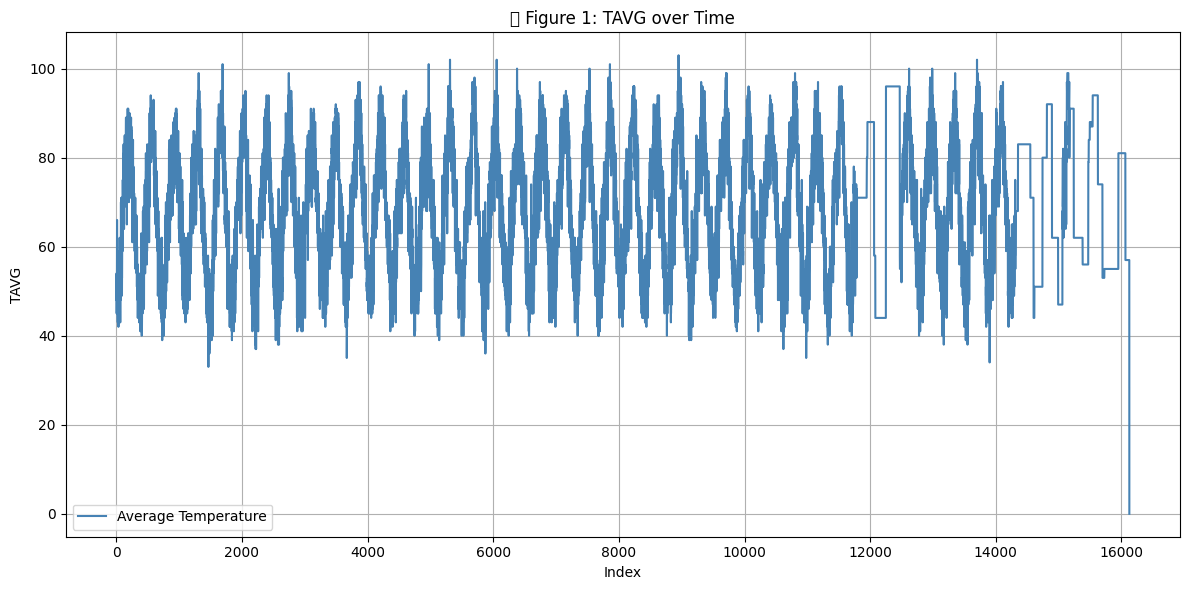

In [82]:
plt.figure(figsize=(12, 6))
plt.plot(weather.index, weather["target"], label="Average Temperature", color="steelblue")
plt.title("📊 Figure 1: TAVG over Time")
plt.xlabel("Index")
plt.ylabel("TAVG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
print(weather.columns)


Index(['STATION', 'NAME', 'PRCP', 'TAVG', 'TMAX', 'TMIN', 'target',
       'rolling_3_TMAX', 'rolling_3_TMAX_pct', 'rolling_3_TMIN',
       'rolling_3_TMIN_pct', 'rolling_3_PRCP', 'rolling_3_PRCP_pct',
       'rolling_14_TMAX', 'rolling_14_TMAX_pct', 'rolling_14_TMIN',
       'rolling_14_TMIN_pct', 'rolling_14_PRCP', 'rolling_14_PRCP_pct',
       'month_avg_TMAX', 'day_avg_TMAX', 'month_avg_TMIN', 'day_avg_TMIN',
       'month_avg_PRCP', 'day_avg_PRCP'],
      dtype='object')


C:\Users\prabh\AppData\Local\Temp\ipykernel_8144\3028563830.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


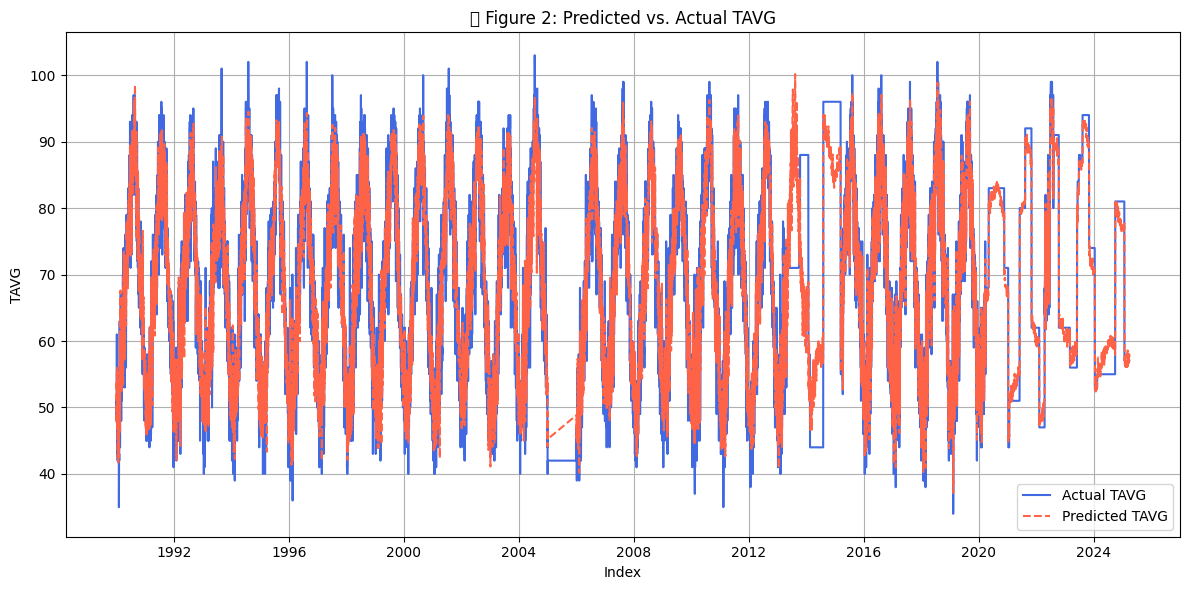

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(predictions.index, predictions["actual"], label="Actual TAVG", color="royalblue")
plt.plot(predictions.index, predictions["predictions"], label="Predicted TAVG", color="tomato", linestyle="--")
plt.title("📊 Figure 2: Predicted vs. Actual TAVG")
plt.xlabel("Index")
plt.ylabel("TAVG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\prabh\AppData\Local\Temp\ipykernel_8144\3837515359.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\prabh\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


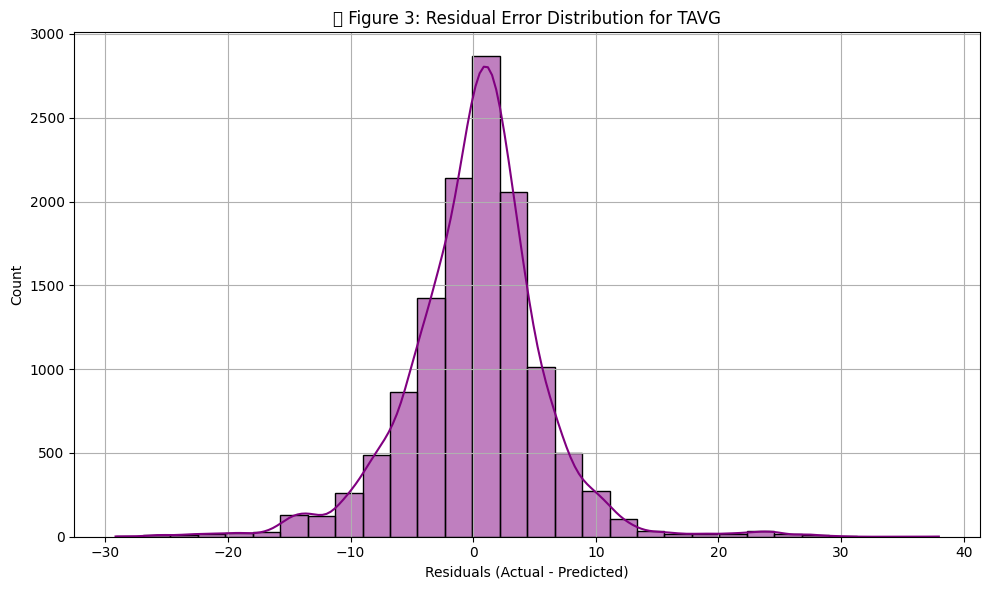

In [84]:
plt.figure(figsize=(10, 6))
residuals = predictions["actual"] - predictions["predictions"]
sns.histplot(residuals, kde=True, color="purple", bins=30)
plt.title("📊 Figure 3: Residual Error Distribution for TAVG")
plt.xlabel("Residuals (Actual - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()
